In [1]:
#Full ANN for predicting how much a taxi is going to charge for a ride
#from a large data set about a variety of taxi rides

#Read in the data
# Feature Engineering (Creating new features from previous features)
    # Calculate Distance
    # Derive useful Date and Time statistics
# Deal with Categorical Data
    # Embedding
# Use TabularModel class to work with both continuous and categorical data

In [2]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../Data/NYCTaxiFares.csv')

In [4]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1


In [6]:
df['fare_amount'].describe()

count    120000.000000
mean         10.040326
std           7.500134
min           2.500000
25%           5.700000
50%           7.700000
75%          11.300000
max          49.900000
Name: fare_amount, dtype: float64

In [8]:
def haversine_distance(df, lat1, long1, lat2, long2):
    """
    Calculates the haversine distance between 2 sets of GPS coordinates in df
    """
    r = 6371  # average radius of Earth in kilometers
       
    phi1 = np.radians(df[lat1])
    phi2 = np.radians(df[lat2])
    
    delta_phi = np.radians(df[lat2]-df[lat1])
    delta_lambda = np.radians(df[long2]-df[long1])
     
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    d = (r * c) # in kilometers

    return d

In [11]:
df['dist_km'] = haversine_distance(df, 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude')

In [10]:
df.columns

Index(['pickup_datetime', 'fare_amount', 'fare_class', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [12]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1,2.126312
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1,1.392307
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2,3.326763
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1,1.864129
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1,7.231321


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 9 columns):
pickup_datetime      120000 non-null object
fare_amount          120000 non-null float64
fare_class           120000 non-null int64
pickup_longitude     120000 non-null float64
pickup_latitude      120000 non-null float64
dropoff_longitude    120000 non-null float64
dropoff_latitude     120000 non-null float64
passenger_count      120000 non-null int64
dist_km              120000 non-null float64
dtypes: float64(6), int64(2), object(1)
memory usage: 8.2+ MB


In [14]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 9 columns):
pickup_datetime      120000 non-null datetime64[ns, UTC]
fare_amount          120000 non-null float64
fare_class           120000 non-null int64
pickup_longitude     120000 non-null float64
pickup_latitude      120000 non-null float64
dropoff_longitude    120000 non-null float64
dropoff_latitude     120000 non-null float64
passenger_count      120000 non-null int64
dist_km              120000 non-null float64
dtypes: datetime64[ns, UTC](1), float64(6), int64(2)
memory usage: 8.2 MB


In [19]:
my_time = df['pickup_datetime'][0]

In [22]:
df['EDTdate'] = df['pickup_datetime'] - pd.Timedelta(hours=4)

In [24]:
df['Hour'] = df['EDTdate'].dt.hour

In [27]:
df['AMorPM'] = np.where(df['Hour']<12, 'AM', 'PM')

In [31]:
df['Weekday'] = df['EDTdate'].dt.strftime('%a')

In [33]:
df.columns

Index(['pickup_datetime', 'fare_amount', 'fare_class', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'dist_km', 'EDTdate', 'Hour', 'AMorPM', 'Weekday'],
      dtype='object')

In [34]:
cat_cols = ['Hour', 'AMorPM', 'Weekday']
cont_cols = ['pickup_longitude','pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'dist_km']

In [35]:
y_col = ['fare_amount']

In [36]:
df.dtypes

pickup_datetime      datetime64[ns, UTC]
fare_amount                      float64
fare_class                         int64
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dist_km                          float64
EDTdate              datetime64[ns, UTC]
Hour                               int64
AMorPM                            object
Weekday                           object
dtype: object

In [38]:
for cat in cat_cols:
    df[cat] = df[cat].astype('category')

In [39]:
df.dtypes

pickup_datetime      datetime64[ns, UTC]
fare_amount                      float64
fare_class                         int64
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dist_km                          float64
EDTdate              datetime64[ns, UTC]
Hour                            category
AMorPM                          category
Weekday                         category
dtype: object

In [40]:
df['Hour'].head()

0     4
1    11
2     7
3    17
4    22
Name: Hour, dtype: category
Categories (24, int64): [0, 1, 2, 3, ..., 20, 21, 22, 23]

In [42]:
df['AMorPM'].head()

0    AM
1    AM
2    AM
3    PM
4    PM
Name: AMorPM, dtype: category
Categories (2, object): [AM, PM]

In [43]:
df['Weekday'].head()

0    Mon
1    Sat
2    Sat
3    Sun
4    Fri
Name: Weekday, dtype: category
Categories (7, object): [Fri, Mon, Sat, Sun, Thu, Tue, Wed]

In [47]:
df['Weekday'].cat.codes.values

array([1, 2, 2, ..., 3, 5, 2], dtype=int8)

In [49]:
hr = df['Hour'].cat.codes.values
ampm = df['AMorPM'].cat.codes.values
wkdy = df['Weekday'].cat.codes.values

In [51]:
cats = np.stack([hr, ampm, wkdy], axis=1)

In [52]:
cats

array([[ 4,  0,  1],
       [11,  0,  2],
       [ 7,  0,  2],
       ...,
       [14,  1,  3],
       [ 4,  0,  5],
       [12,  1,  2]], dtype=int8)

In [53]:
# conts = np.stack([df[col].values for col in cont_cols], 1)

In [54]:
cats = torch.tensor(cats, dtype=torch.int64)

In [55]:
conts = np.stack([df[col].values for col in cont_cols],axis=1)

In [56]:
conts

array([[-73.992365  ,  40.730521  , -73.975499  ,  40.744746  ,
          1.        ,   2.12631159],
       [-73.990078  ,  40.740558  , -73.974232  ,  40.744114  ,
          1.        ,   1.39230687],
       [-73.994149  ,  40.751118  , -73.960064  ,  40.766235  ,
          2.        ,   3.32676344],
       ...,
       [-73.988574  ,  40.749772  , -74.011541  ,  40.707799  ,
          3.        ,   5.05252282],
       [-74.004449  ,  40.724529  , -73.992697  ,  40.730765  ,
          1.        ,   1.20892296],
       [-73.955415  ,  40.77192   , -73.967623  ,  40.763015  ,
          3.        ,   1.42739869]])

In [57]:
conts = torch.tensor(conts, dtype=torch.float)

In [58]:
conts

tensor([[-73.9924,  40.7305, -73.9755,  40.7447,   1.0000,   2.1263],
        [-73.9901,  40.7406, -73.9742,  40.7441,   1.0000,   1.3923],
        [-73.9941,  40.7511, -73.9601,  40.7662,   2.0000,   3.3268],
        ...,
        [-73.9886,  40.7498, -74.0115,  40.7078,   3.0000,   5.0525],
        [-74.0044,  40.7245, -73.9927,  40.7308,   1.0000,   1.2089],
        [-73.9554,  40.7719, -73.9676,  40.7630,   3.0000,   1.4274]])

In [65]:
y = torch.tensor(df[y_col].values, dtype=torch.float)

In [61]:
cats.shape

torch.Size([120000, 3])

In [62]:
conts.shape

torch.Size([120000, 6])

In [66]:
y.shape

torch.Size([120000, 1])

In [99]:
cat_szs = [len(df[col].cat.categories) for col in cat_cols]

In [100]:
cat_szs

[24, 2, 7]

In [101]:
emb_szs = [(size,min(50, (size+1)//2)) for size in cat_szs]

In [102]:
emb_szs

[(24, 12), (2, 1), (7, 4)]

In [103]:
catz = cats[:2]

In [104]:
catz

tensor([[ 4,  0,  1],
        [11,  0,  2]])

In [105]:
selfembeds = nn.ModuleList([nn.Embedding(ni,nf) for ni,nf in emb_szs])

In [106]:
selfembeds

ModuleList(
  (0): Embedding(24, 12)
  (1): Embedding(2, 1)
  (2): Embedding(7, 4)
)

In [107]:
embeddingz = []

for i,e in enumerate(selfembeds):
    embeddingz.append(e(catz[:,i]))

In [108]:
embeddingz

[tensor([[ 0.9768,  0.4018, -0.5784, -1.3879,  1.6456,  0.5809, -0.0250,  1.6507,
           0.8200, -0.2960,  0.7227,  0.2994],
         [ 1.9967, -0.2996, -0.2469, -0.5349,  0.5457,  0.6808,  0.6310,  1.2922,
          -0.7902, -1.2958, -1.2216, -0.6571]], grad_fn=<EmbeddingBackward0>),
 tensor([[0.2261],
         [0.2261]], grad_fn=<EmbeddingBackward0>),
 tensor([[ 0.2238, -0.4656, -1.4116,  1.6594],
         [ 1.2743, -0.5816, -0.1533,  0.5730]], grad_fn=<EmbeddingBackward0>)]

In [109]:
z = torch.cat(embeddingz,1)

In [110]:
z

tensor([[ 0.9768,  0.4018, -0.5784, -1.3879,  1.6456,  0.5809, -0.0250,  1.6507,
          0.8200, -0.2960,  0.7227,  0.2994,  0.2261,  0.2238, -0.4656, -1.4116,
          1.6594],
        [ 1.9967, -0.2996, -0.2469, -0.5349,  0.5457,  0.6808,  0.6310,  1.2922,
         -0.7902, -1.2958, -1.2216, -0.6571,  0.2261,  1.2743, -0.5816, -0.1533,
          0.5730]], grad_fn=<CatBackward0>)

In [111]:
selfembdrop = nn.Dropout(0.4)
z = selfembdrop(z)

In [112]:
z

tensor([[ 1.6280,  0.6696, -0.9640, -2.3132,  0.0000,  0.0000, -0.0000,  2.7512,
          0.0000, -0.0000,  0.0000,  0.4990,  0.0000,  0.3730, -0.7761, -2.3527,
          2.7656],
        [ 3.3279, -0.4993, -0.4115, -0.8916,  0.9094,  1.1347,  0.0000,  2.1537,
         -0.0000, -0.0000, -2.0360, -1.0952,  0.0000,  0.0000, -0.0000, -0.0000,
          0.9550]], grad_fn=<MulBackward0>)

In [130]:
class TabularModel(nn.Module):
    
    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        
        # Layers = [200 neurons, 100 neurons, 50 neurons]
        
        super().__init__()
        
        self.embeds = nn.ModuleList([nn.Embedding(ni,nf) for ni,nf in emb_szs])
        self.emb_drop = nn.Dropout(p)
        self.bn_cont = nn.BatchNorm1d(n_cont)
        
        layerlist = []
        n_emb = sum([nf for ni,nf in emb_szs])
        n_in = n_emb + n_cont
        
        for i in layers:
            layerlist.append(nn.Linear(n_in,i))
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i
            
        layerlist.append(nn.Linear(layers[-1], out_sz)) 
        
        self.layers = nn.Sequential(*layerlist)
            
    def forward(self,x_cat,x_cont):
        embeddings = []
        
        for i,e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:,i]))
            
        x = torch.cat(embeddings, 1)
        x = self.emb_drop(x)
        
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x,x_cont], 1)
        x = self.layers(x)
        
        return x

In [131]:
torch.manual_seed(33)
model = TabularModel(emb_szs,conts.shape[1], 1, [200,100], p=0.4)

In [132]:
model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(24, 12)
    (1): Embedding(2, 1)
    (2): Embedding(7, 4)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=23, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [134]:
criterion = nn.MSELoss() # np.sqrt(MSE) --> RMSE
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [135]:
batch_size = 60000
test_size = int(batch_size*0.2)

In [143]:
# DATA SHUFFLED ALREADY
cat_train = cats[:batch_size-test_size]
cat_test = cats[batch_size-test_size:batch_size]
con_train = conts[:batch_size-test_size]
con_test = conts[batch_size-test_size:batch_size]

In [144]:
y_train = y[:batch_size-test_size]
y_test = y[batch_size-test_size:batch_size]

In [145]:
len(cat_train)

48000

In [146]:
len(con_train)

48000

In [147]:
len(cat_test)

12000

In [149]:
import time

start_time = time.time()

epochs = 300

losses = []

for i in range(epochs):
    i += 1
    
    y_pred = model(cat_train, con_train)
    loss = torch.sqrt(criterion(y_pred, y_train))
    losses.append(loss)
    
    if i%10 == 1:
        print(f'epoch: {i} loss is {loss}')
        
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
duration = time.time() - start_time
print(f'Training took {duration/60} minutes')

epoch: 1 loss is 12.59089469909668
epoch: 11 loss is 11.688835144042969
epoch: 21 loss is 11.119146347045898
epoch: 31 loss is 10.73538589477539
epoch: 41 loss is 10.456839561462402
epoch: 51 loss is 10.23055648803711
epoch: 61 loss is 10.030854225158691
epoch: 71 loss is 9.839005470275879
epoch: 81 loss is 9.639872550964355
epoch: 91 loss is 9.417255401611328
epoch: 101 loss is 9.176578521728516
epoch: 111 loss is 8.891666412353516
epoch: 121 loss is 8.574406623840332
epoch: 131 loss is 8.215409278869629
epoch: 141 loss is 7.811830997467041
epoch: 151 loss is 7.38257360458374
epoch: 161 loss is 6.920592784881592
epoch: 171 loss is 6.447607040405273
epoch: 181 loss is 5.971290588378906
epoch: 191 loss is 5.487194061279297
epoch: 201 loss is 5.018258094787598
epoch: 211 loss is 4.647674560546875
epoch: 221 loss is 4.308317184448242
epoch: 231 loss is 4.075559139251709
epoch: 241 loss is 3.959900379180908
epoch: 251 loss is 3.870896577835083
epoch: 261 loss is 3.818603277206421
epoch: 27

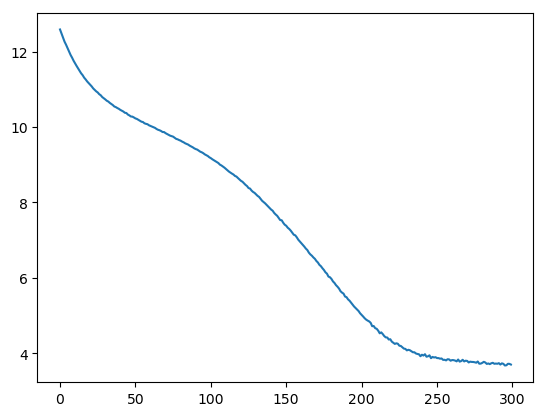

In [151]:
plt.plot(range(epochs),losses)

In [152]:
with torch.no_grad():
    
    y_val = model(cat_test, con_test)
    
    loss = torch.sqrt(criterion(y_val, y_test))

In [153]:
loss

tensor(3.5981)

In [159]:
for i in range(10):
    diff = np.abs(y_val[i].item() - y_test[i].item())
    print(f' {i}.) PREDICTED: {y_val[i].item():8.2f} TRUE: {y_test[i].item():8.2f} DIFF: {diff:8.2f}')

 0.) PREDICTED:     1.31 TRUE:     2.90 DIFF:     1.59
 1.) PREDICTED:    17.30 TRUE:     5.70 DIFF:    11.60
 2.) PREDICTED:     6.63 TRUE:     7.70 DIFF:     1.07
 3.) PREDICTED:    13.58 TRUE:    12.50 DIFF:     1.08
 4.) PREDICTED:     4.50 TRUE:     4.10 DIFF:     0.40
 5.) PREDICTED:     8.08 TRUE:     5.30 DIFF:     2.78
 6.) PREDICTED:     0.77 TRUE:     3.70 DIFF:     2.93
 7.) PREDICTED:    15.66 TRUE:    14.50 DIFF:     1.16
 8.) PREDICTED:     5.05 TRUE:     5.70 DIFF:     0.65
 9.) PREDICTED:     9.06 TRUE:    10.10 DIFF:     1.04


In [160]:
torch.save(model.state_dict(), 'TaxiModel.pt')